# Домашнее задание №9: Автокодировщик

**Студент**: Сизиков Константин

**Цель**: Разберемся с тем, как работает автокодировщик и что содержится в латентном представлении данных.

**Описание/Пошаговая инструкция выполнения домашнего задания**:
1. **Обучить многослойный автокодировщик**:
 - отрисовать классы в латентном представлении автокодировщика с двумерным латентным слоем
 - сделать tSNE над 32-мерным латентным слоем, отрисовать представление

2. **Обучить шумный автокодировщик**:
 - Добавить ко входным данным нормальный шум
 - Сделать отражение части изображения
 - Отрисовать карты активаций нейронов первого слоя

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 1. Загрузка данных (MNIST)

train: 60000, test: 10000


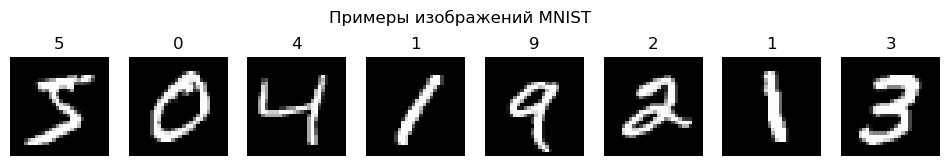

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=2)

print(f'train: {len(train_dataset)}, test: {len(test_dataset)}')

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img[0], cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')
plt.suptitle('Примеры изображений MNIST')
plt.show()

## 2. Часть 1. Многослойный автокодировщик

Полносвязный автокодировщик `784 -> 256 -> 64 -> latent_dim -> 64 -> 256 -> 784`. Параметр `latent_dim` варьируем: 2 (для визуализации латентного пространства напрямую) и 32 (для визуализации через t-SNE).

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28), z

In [4]:
def train_autoencoder(model, loader, epochs=15, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for x, _ in loader:
            x = x.to(device)
            opt.zero_grad()
            x_hat, _ = model(x)
            loss = criterion(x_hat, x)
            loss.backward()
            opt.step()
            running_loss += loss.item() * x.size(0)
        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        print(f'Epoch {epoch + 1}/{epochs}, loss={epoch_loss:.5f}')
    return history


def get_latents(model, loader):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, z = model(x)
            zs.append(z.cpu().numpy())
            ys.append(y.numpy())
    return np.concatenate(zs), np.concatenate(ys)

### 2.1 Автокодировщик с двумерным латентным слоем

Epoch 1/15, loss=0.06943
Epoch 2/15, loss=0.05279
Epoch 3/15, loss=0.05039
Epoch 4/15, loss=0.04777
Epoch 5/15, loss=0.04596
Epoch 6/15, loss=0.04476
Epoch 7/15, loss=0.04385
Epoch 8/15, loss=0.04311
Epoch 9/15, loss=0.04258
Epoch 10/15, loss=0.04210
Epoch 11/15, loss=0.04172
Epoch 12/15, loss=0.04137
Epoch 13/15, loss=0.04102
Epoch 14/15, loss=0.04073
Epoch 15/15, loss=0.04042


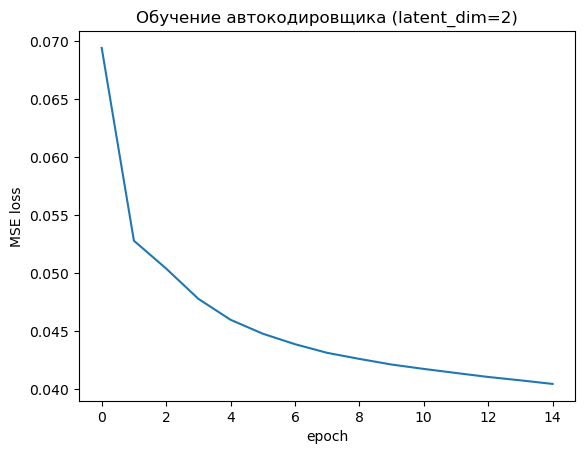

In [5]:
ae2 = Autoencoder(latent_dim=2)
history2 = train_autoencoder(ae2, train_loader, epochs=15)

plt.plot(history2)
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.title('Обучение автокодировщика (latent_dim=2)')
plt.show()

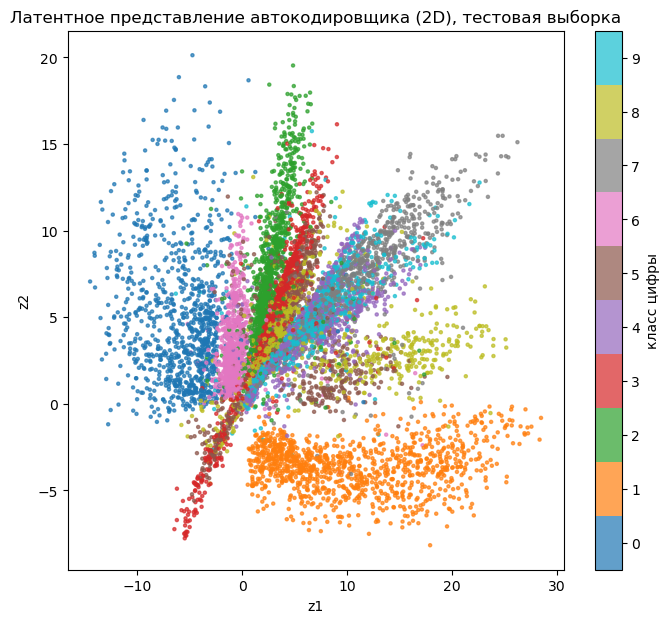

In [6]:
z2, y2 = get_latents(ae2, test_loader)

# дискретная палитра на 10 классов: деления colorbar попадают в центр цветовой полосы
cmap10 = plt.get_cmap('tab10', 10)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(z2[:, 0], z2[:, 1], c=y2, cmap=cmap10, vmin=-0.5, vmax=9.5, s=5, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='класс цифры')
plt.title('Латентное представление автокодировщика (2D), тестовая выборка')
plt.xlabel('z1'); plt.ylabel('z2')
plt.show()

**Что видно на графике.** Обучение было полностью unsupervised — метки классов нигде не использовались, они нужны только для раскраски. Тем не менее объекты одного класса занимают в латентном пространстве связные области: хорошо обособлены «0» и «1», заметно отделяются «6» и «2».

При этом разделение далеко не идеальное: в центральной части облака классы сильно перемешаны — прежде всего визуально похожие «4», «7», «9» и группа «3», «5», «8». Это ожидаемо: двух чисел физически не хватает, чтобы закодировать все вариации начертания цифр, и автокодировщик вынужден жертвовать различимостью классов ради качества восстановления. Кроме того, автокодировщик не имеет никакого стимула разделять классы — он оптимизирует только ошибку реконструкции, а кластеризация по классам возникает лишь как побочный эффект того, что похожие изображения кодируются похожими векторами.

Сравним реконструкции с оригиналами:

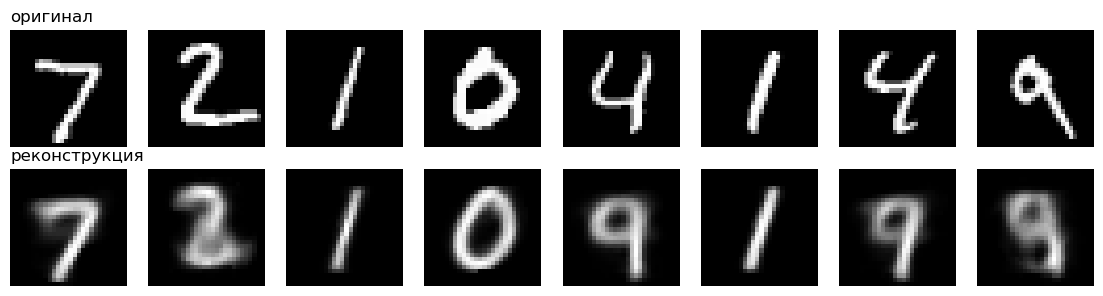

In [7]:
def show_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    with torch.no_grad():
        x_hat, _ = model(x)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap='gray'); axes[0, i].axis('off')
        axes[1, i].imshow(x_hat[i, 0].cpu(), cmap='gray'); axes[1, i].axis('off')
    axes[0, 0].set_title('оригинал', loc='left')
    axes[1, 0].set_title('реконструкция', loc='left')
    plt.tight_layout()
    plt.show()

show_reconstructions(ae2, test_loader)

### 2.2 Автокодировщик с 32-мерным латентным слоем + t-SNE

Epoch 1/15, loss=0.06871
Epoch 2/15, loss=0.03460
Epoch 3/15, loss=0.02676
Epoch 4/15, loss=0.02290
Epoch 5/15, loss=0.02031
Epoch 6/15, loss=0.01804
Epoch 7/15, loss=0.01644
Epoch 8/15, loss=0.01516
Epoch 9/15, loss=0.01420
Epoch 10/15, loss=0.01350
Epoch 11/15, loss=0.01292
Epoch 12/15, loss=0.01243
Epoch 13/15, loss=0.01196
Epoch 14/15, loss=0.01147
Epoch 15/15, loss=0.01103


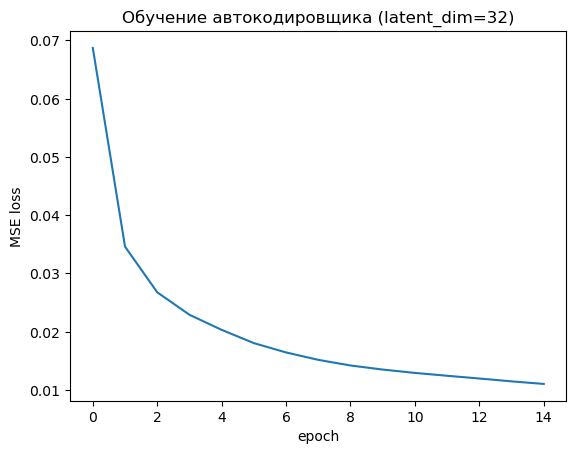

In [8]:
ae32 = Autoencoder(latent_dim=32)
history32 = train_autoencoder(ae32, train_loader, epochs=15)

plt.plot(history32)
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.title('Обучение автокодировщика (latent_dim=32)')
plt.show()

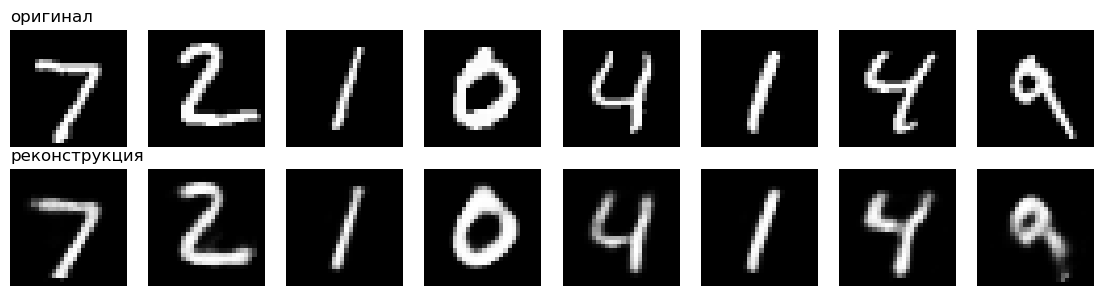

In [9]:
show_reconstructions(ae32, test_loader)

размерность латентного представления: (10000, 32)


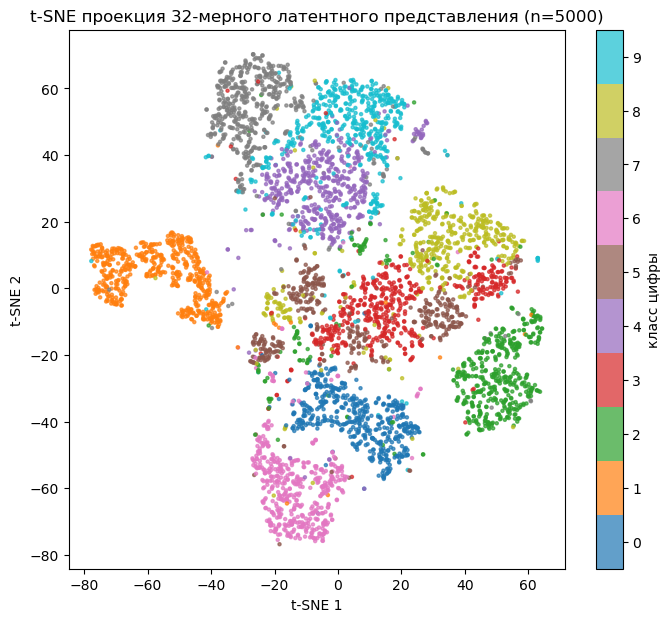

In [10]:
z32, y32 = get_latents(ae32, test_loader)
print('размерность латентного представления:', z32.shape)

# t-SNE — дорогая операция, используем подвыборку
n_sub = 5000
idx = np.random.choice(len(z32), n_sub, replace=False)
z32_sub, y32_sub = z32[idx], y32[idx]

tsne = TSNE(n_components=2, random_state=SEED, init='pca', perplexity=30)
z32_tsne = tsne.fit_transform(z32_sub)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(z32_tsne[:, 0], z32_tsne[:, 1], c=y32_sub, cmap=cmap10, vmin=-0.5, vmax=9.5, s=5, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='класс цифры')
plt.title(f't-SNE проекция 32-мерного латентного представления (n={n_sub})')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.show()

**Что видно на графике.** В 32-мерном пространстве кластеры классов разделяются заметно лучше, чем в 2-мерном: большинство цифр образуют компактные, хорошо обособленные группы. Причина в том, что 32 числа дают автокодировщику достаточно «места», чтобы одновременно и точно восстанавливать изображение, и разносить непохожие объекты далеко друг от друга — что подтверждается и ошибкой реконструкции (итоговый MSE у 32-мерной модели примерно в 3–4 раза ниже, чем у 2-мерной), и заметно более чёткими реконструкциями выше.

Кластеры при этом не изолированы: соседствуют и частично перемешиваются на границах ожидаемо похожие по начертанию классы — «4», «7», «9» образуют смежную область, и рядом же располагаются «3», «5», «8». Автокодировщик не использует метки, поэтому близкие по виду цифры он кодирует близкими векторами.

**Важная оговорка про t-SNE.** Это два принципиально разных графика, и сравнивать их нужно осторожно:
- в п. 2.1 мы рисовали *само* латентное пространство — оси `z1`, `z2` это реальные координаты кода, и расстояния в них те же, с которыми работает декодер;
- здесь мы рисуем не латентное пространство, а его нелинейную проекцию, специально подобранную t-SNE так, чтобы сохранить соседство точек. Оси t-SNE не имеют содержательного смысла, а расстояния *между* кластерами и их размеры интерпретировать нельзя — t-SNE достоверно передаёт только локальную структуру (кто чьи соседи). Результат также зависит от `perplexity` и инициализации.

Иначе говоря, чёткие кластеры на t-SNE означают «в 32-мерном представлении объекты одного класса являются ближайшими соседями друг друга», а не «классы линейно разделимы именно так, как показано на картинке».

## 3. Часть 2. Шумный (denoising) автокодировщик

Ко входному изображению применяем два вида искажений (целевым выходом при этом остаётся **чистое** изображение):
1. **Нормальный (гауссовский) шум** — к каждому пикселю добавляется $N(0, \sigma^2)$, $\sigma = 0.4$, результат обрезается в диапазон $[0, 1]$.
2. **Отражение части изображения** — у каждого изображения независимо выбирается случайная вертикальная полоса шириной 40% ширины кадра, и её содержимое заменяется собственным зеркальным отражением.

Такой автокодировщик учится не просто копировать вход (что для обычного автокодировщика — вырожденное решение), а восстанавливать неискажённое изображение по испорченному. Это заставляет его опираться на структуру данных: он вынужден «понимать», как выглядит цифра, чтобы отличить сигнал от шума и от неверно отражённого фрагмента.

Здесь используем **свёрточную** архитектуру (в отличие от полносвязной в части 1) — у свёрточного слоя есть пространственные карты активаций, которые можно осмысленно визуализировать в п. 3.2.

In [11]:
def add_noise_and_reflection(x, noise_std=0.4, reflect_frac=0.4):
    """Искажает батч изображений: отражение части изображения + нормальный шум.

    x: тензор (B, 1, 28, 28) со значениями в [0, 1].
    Для КАЖДОГО изображения независимо выбирается вертикальная полоса ширины
    reflect_frac * W, содержимое которой заменяется своим зеркальным отражением,
    после чего добавляется гауссовский шум N(0, noise_std^2).
    """
    B, C, H, W = x.shape
    w = max(1, int(W * reflect_frac))

    # своя позиция полосы для каждого изображения в батче
    starts = torch.randint(0, W - w + 1, (B,), device=x.device)
    cols = torch.arange(W, device=x.device).expand(B, W)
    inside = (cols >= starts[:, None]) & (cols < starts[:, None] + w)

    # внутри полосы столбец j берётся из зеркального столбца 2*start + w - 1 - j
    mirrored = 2 * starts[:, None] + w - 1 - cols
    src = torch.where(inside, mirrored, cols)

    x_noisy = torch.gather(x, 3, src[:, None, None, :].expand(B, C, H, W))
    x_noisy = x_noisy + torch.randn_like(x_noisy) * noise_std
    return x_noisy.clamp(0., 1.)

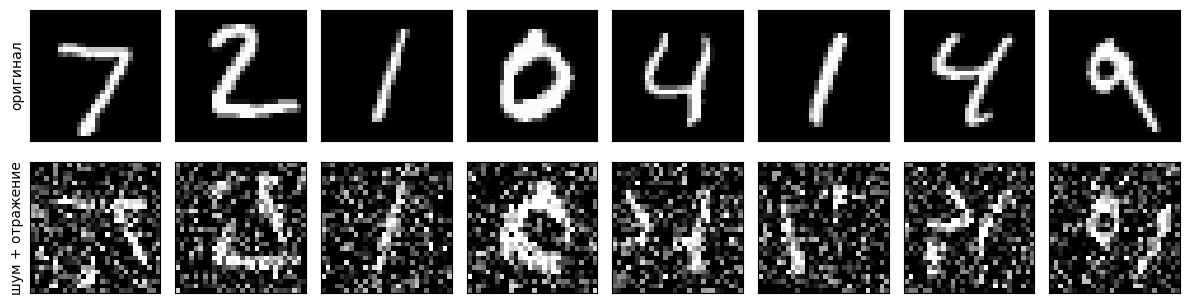

In [12]:
# Проверим, как выглядит искажение (полоса отражения у каждого изображения своя)
x_demo, _ = next(iter(test_loader))
x_demo = x_demo[:8]
x_demo_noisy = add_noise_and_reflection(x_demo)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(x_demo[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(x_demo_noisy[i, 0], cmap='gray', vmin=0, vmax=1)
    for r in range(2):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel('оригинал', fontsize=10)
axes[1, 0].set_ylabel('шум + отражение', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)   # 28x28 -> 14x14
        self.enc2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)  # 14x14 -> 7x7
        self.enc3 = nn.Conv2d(32, 64, kernel_size=7)                      # 7x7 -> 1x1 (bottleneck)

        self.dec1 = nn.ConvTranspose2d(64, 32, kernel_size=7)                                   # 1x1 -> 7x7
        self.dec2 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)  # 7x7 -> 14x14
        self.dec3 = nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)   # 14x14 -> 28x28

    def forward(self, x):
        a1 = F.relu(self.enc1(x))   # карты активаций первого слоя: (B, 16, 14, 14)
        a2 = F.relu(self.enc2(a1))
        z = F.relu(self.enc3(a2))

        d1 = F.relu(self.dec1(z))
        d2 = F.relu(self.dec2(d1))
        x_hat = torch.sigmoid(self.dec3(d2))
        return x_hat, a1

Epoch 1/15, loss=0.07907
Epoch 2/15, loss=0.06046
Epoch 3/15, loss=0.04596
Epoch 4/15, loss=0.03882
Epoch 5/15, loss=0.03533
Epoch 6/15, loss=0.03305
Epoch 7/15, loss=0.03133
Epoch 8/15, loss=0.03010
Epoch 9/15, loss=0.02922
Epoch 10/15, loss=0.02842
Epoch 11/15, loss=0.02783
Epoch 12/15, loss=0.02728
Epoch 13/15, loss=0.02684
Epoch 14/15, loss=0.02641
Epoch 15/15, loss=0.02605


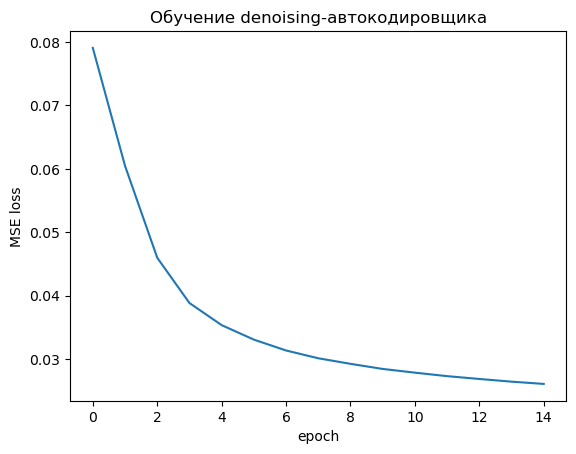

In [14]:
def train_denoising_autoencoder(model, loader, epochs=15, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for x, _ in loader:
            x = x.to(device)
            x_noisy = add_noise_and_reflection(x)   # вход — искажённое изображение
            opt.zero_grad()
            x_hat, _ = model(x_noisy)
            loss = criterion(x_hat, x)              # цель — ЧИСТОЕ изображение
            loss.backward()
            opt.step()
            running_loss += loss.item() * x.size(0)
        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        print(f'Epoch {epoch + 1}/{epochs}, loss={epoch_loss:.5f}')
    return history


dae = ConvAutoencoder()
history_dae = train_denoising_autoencoder(dae, train_loader, epochs=15)

plt.plot(history_dae)
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.title('Обучение denoising-автокодировщика')
plt.show()

### 3.1 Примеры очистки зашумлённых изображений

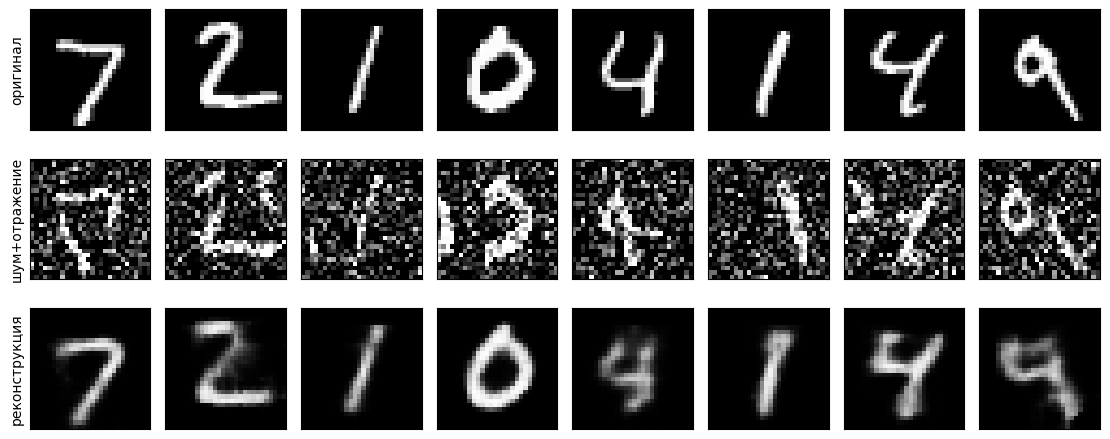

MSE(искажённый вход, оригинал) = 0.1276
MSE(реконструкция,   оригинал) = 0.0249


In [15]:
dae.eval()
n_show = 8
x_batch, _ = next(iter(test_loader))
x_batch = x_batch[:n_show].to(device)
x_noisy_batch = add_noise_and_reflection(x_batch)
with torch.no_grad():
    x_hat_batch, _ = dae(x_noisy_batch)

row_labels = ['оригинал', 'шум+отражение', 'реконструкция']
rows = [x_batch, x_noisy_batch, x_hat_batch]

fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.4, 4.8))
for r in range(3):
    for i in range(n_show):
        axes[r, i].imshow(rows[r][i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
    axes[r, 0].set_ylabel(row_labels[r], fontsize=10)
plt.tight_layout()
plt.show()

# численная оценка: насколько реконструкция ближе к оригиналу, чем искажённый вход
mse_noisy = F.mse_loss(x_noisy_batch, x_batch).item()
mse_recon = F.mse_loss(x_hat_batch, x_batch).item()
print(f'MSE(искажённый вход, оригинал) = {mse_noisy:.4f}')
print(f'MSE(реконструкция,   оригинал) = {mse_recon:.4f}')

### 3.2 Карты активаций нейронов первого слоя

Первый свёрточный слой `enc1` — это `Conv2d(1, 16, kernel_size=3, stride=2, padding=1)`: 16 фильтров размера 3×3, каждый из которых даёт свою карту активаций 14×14 (разрешение вдвое ниже входного из-за `stride=2`). Карта активаций показывает, **в каких местах изображения** сработал конкретный нейрон-фильтр.

Подадим на вход одно искажённое изображение и посмотрим отклик каждого из 16 фильтров.

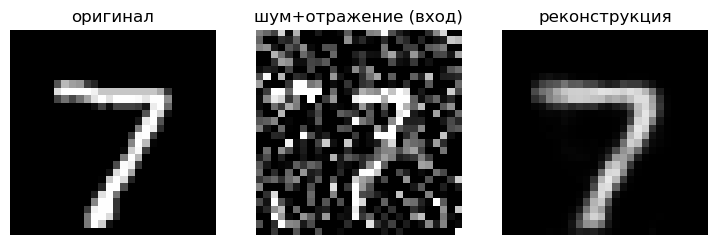

форма тензора активаций первого слоя: (1, 16, 14, 14)


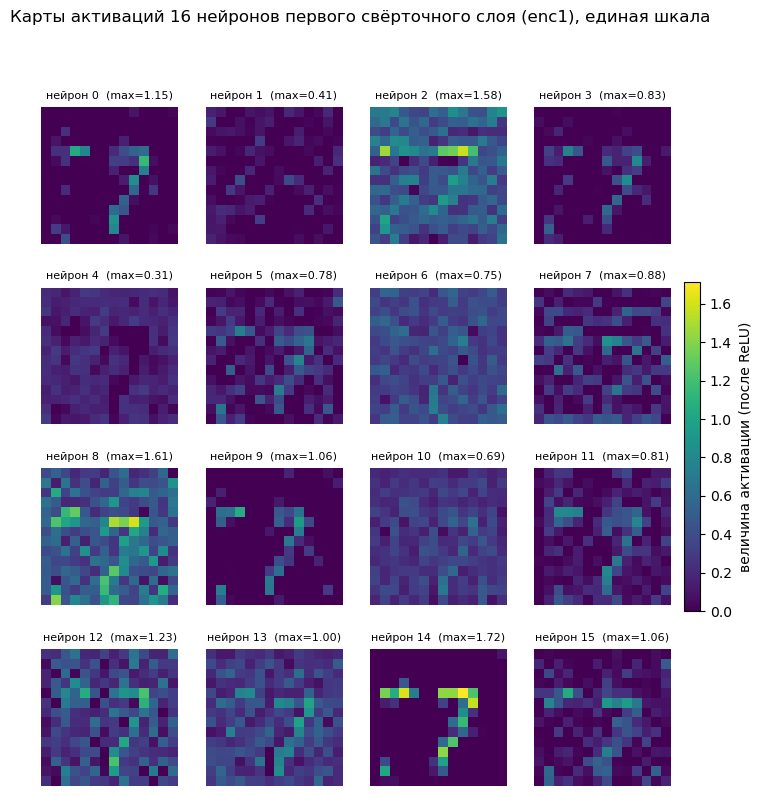

In [16]:
x_sample, _ = next(iter(test_loader))
x_sample = x_sample[:1].to(device)
x_sample_noisy = add_noise_and_reflection(x_sample)

with torch.no_grad():
    x_hat, act1 = dae(x_sample_noisy)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(x_sample[0, 0].cpu(), cmap='gray', vmin=0, vmax=1); axes[0].set_title('оригинал'); axes[0].axis('off')
axes[1].imshow(x_sample_noisy[0, 0].cpu(), cmap='gray', vmin=0, vmax=1); axes[1].set_title('шум+отражение (вход)'); axes[1].axis('off')
axes[2].imshow(x_hat[0, 0].cpu(), cmap='gray', vmin=0, vmax=1); axes[2].set_title('реконструкция'); axes[2].axis('off')
plt.show()

act1_np = act1[0].cpu().numpy()  # (16, 14, 14) — по карте на каждый из 16 фильтров
print('форма тензора активаций первого слоя:', tuple(act1.shape))

# ВАЖНО: единая шкала цвета для всех карт, иначе слабо активный нейрон
# выглядел бы таким же ярким, как сильно активный (imshow масштабирует каждую картинку отдельно)
vmax = act1_np.max()

fig, axes = plt.subplots(4, 4, figsize=(8.5, 9))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(act1_np[i], cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(f'нейрон {i}  (max={act1_np[i].max():.2f})', fontsize=8)
    ax.axis('off')
fig.suptitle('Карты активаций 16 нейронов первого свёрточного слоя (enc1), единая шкала', y=0.98)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='величина активации (после ReLU)')
plt.show()

**Что видно на картах активаций.** Все 16 карт отрисованы в единой цветовой шкале, поэтому яркость можно сравнивать между нейронами напрямую.

- Фильтры реагируют **локально и по-разному**: у одних отклик повторяет контур цифры (нейрон «видит» штрих под определённым наклоном или перепад яркости определённого знака), у других максимум приходится на фон и на области, куда шум и зеркальное отражение внесли артефакты.
- Часть нейронов заметно «тусклее» остальных (маленькое значение `max`) — после ReLU они почти не активируются на этом конкретном входе: каждый фильтр специализируется на своём типе локального признака, и не все признаки присутствуют в одном изображении.
- Первый слой ещё не кодирует «цифру целиком» — это низкоуровневые детекторы края/штриха/контраста с рецептивным полем всего 3×3 пикселя. Обобщение до формы цифры происходит глубже: к бутылочному горлышку `enc3` всё изображение сжимается в 64 числа.

Именно в этом суть denoising-автокодировщика: чтобы восстановить чистое изображение, сеть не может просто скопировать вход — ей приходится на первых слоях выделять устойчивые локальные признаки штрихов, а на глубоких — «собирать» из них правдоподобную цифру, отбрасывая шум и искажённый отражением фрагмент.

## 4. Итоговые выводы

**Что содержится в латентном представлении.** Автокодировщик обучается без меток и оптимизирует только ошибку восстановления, но в его латентном коде всё равно оказывается информация о классе: похожие изображения получают близкие коды, поэтому цифры одного класса образуют в латентном пространстве связные области. Классовая структура возникает как побочный продукт сжатия, а не как цель обучения — поэтому визуально похожие цифры («4»/«7»/«9», «3»/«5»/«8») систематически перемешиваются.

**Влияние размерности латентного слоя.**

| Модель | latent_dim | Итоговый MSE | Разделение классов |
|---|---|---|---|
| Полносвязный AE | 2 | ≈0.040 | Частичное, сильные пересечения в центре облака |
| Полносвязный AE | 32 | ≈0.011 | Чёткое (по t-SNE), пересечения только между похожими цифрами |

Два числа — жёсткое ограничение: их хватает на грубое расположение классов, но не на детали начертания, из-за чего реконструкции размыты. 32 измерения дают ошибку примерно в 3.7 раза меньше и более уверенное разделение классов. Плата за это — латентное пространство больше нельзя нарисовать напрямую, нужна проекция (t-SNE), которая достоверно передаёт лишь локальное соседство точек.

**Шумный (denoising) автокодировщик** решает более содержательную задачу: вход искажён (гауссовский шум + зеркально отражённая полоса), а цель — чистое изображение. Тождественное отображение перестаёт быть решением, поэтому сеть вынуждена опираться на структуру данных. Количественно это видно по замеру в п. 3.1: искажённый вход отстоит от оригинала на MSE ≈ 0.13, а реконструкция — лишь на ≈ 0.025, то есть сеть убирает основную часть искажения.

На картах активаций первого слоя видно, что фильтры работают как локальные детекторы штрихов и перепадов яркости и специализируются каждый на своём признаке (на одном и том же входе максимумы активаций различаются в разы), а сборка изображения цифры целиком происходит глубже — через бутылочное горлышко из 64 чисел.